In [70]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
cm_number = 10
cm = plt.cm.get_cmap("Blues")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset, zoomed_inset_axes
mpl.rc('font', family='Arial')
mpl.rc('font',size = 8)
mpl.rc('mathtext',fontset = 'stix')
mpl.rc('xtick', labelsize=6)
mpl.rc('ytick', labelsize=6)
# mpl.rc('xtick', labelsize=4)
# mpl.rc('ytick', labelsize=4)
mpl.rc('axes', labelsize=8)
mpl.rc('axes', labelpad=1)
mpl.rc('axes', titlesize=8)
mpl.rc('axes', linewidth=0.5)
figsavepath = "../../Elements/Numerical"

C:\Users\TengMa\AppData\Local\Temp\ipykernel_24980\2347785675.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap("Blues")


In [27]:
import h5py
import numpy as np

GT = [[],[]]
PRE = [[],[]]
s = np.linspace(0.25,1.5,6)
for i in s:
    P = './frfs/GT_%.2f.mat'%i
    data = scipy.io.loadmat(P)
    GT[0].append(data['frf'][:,0])
    GT[1].append(data['frf'][:,1])
    P = './frfs/PRE_%.2f.mat'%i
    data = scipy.io.loadmat(P)
    PRE[0].append(data['frf'][:,0])
    PRE[1].append(data['frf'][:,1])

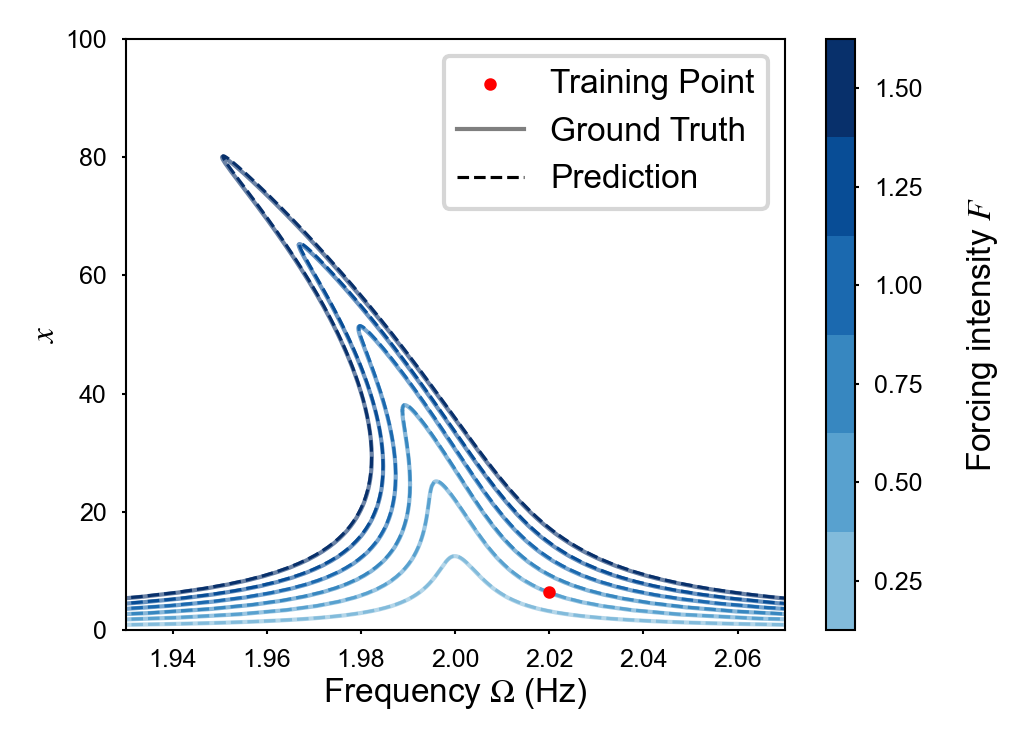

In [76]:
fig, ax = plt.subplots(figsize = (9/2.54, 6.5/2.54),dpi = 300)
for i in range(len(s)):
    ax.plot(GT[0][i],GT[1][i],alpha = 0.6, color = colors[i+4],ls = '-',lw = 1)
    ax.plot(PRE[0][i],PRE[1][i], color = colors[i+4],ls = '--',lw = 0.75)
ax.scatter([2.02],[6.4], color = 'red', s = 4,zorder = 100,label = 'Training Point')
ax.plot([0,0],[1,1],ls = '-',alpha = 0.5,lw = 1,color = 'black',label = 'Ground Truth')
ax.plot([0,0],[1,1],ls = '--',alpha = 1,lw = 0.75,color = 'black',label = 'Prediction')
ax.set_xlim(1.93,2.07)
ax.set_ylim(0,100)
ax.set_xlabel(r"Frequency $\Omega$ (Hz)")
ax.set_ylabel(r"$x$")
ax.legend()
cmap_discrete = mpl.colors.ListedColormap(colors[4:])
bounds = list(range(4, cm_number+1))
norm = mpl.colors.BoundaryNorm(bounds, cmap_discrete.N)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_discrete)
sm.set_array([])
tick_positions = [4.5, 5.5, 6.5, 7.5, 8.5, 9.5]
# 你可以根据实际意义随意改 label 文本
tick_labels = ['0.25','0.50','0.75','1.00','1.25','1.50']  
ax.tick_params(direction='out',width = 0.5,length = 1)
cbar = fig.colorbar(sm, ax=ax, ticks=tick_positions)
cbar.ax.set_yticklabels(tick_labels)
cbar.set_label("Forcing intensity $F$",labelpad = 10)
cbar.ax.minorticks_off()
cbar.ax.tick_params(direction='out',width = 0.5,length = 1)
plt.savefig("%s/FRF.pdf"%figsavepath,dpi = 300,transparent = True,bbox_inches="tight")

In [77]:
import scipy.io
P = './frfs/GT_1.00.mat'
a = scipy.io.loadmat('../Simulations/mirror_matcont.mat')


In [79]:
a['xlcc'].shape

(3212, 2000)

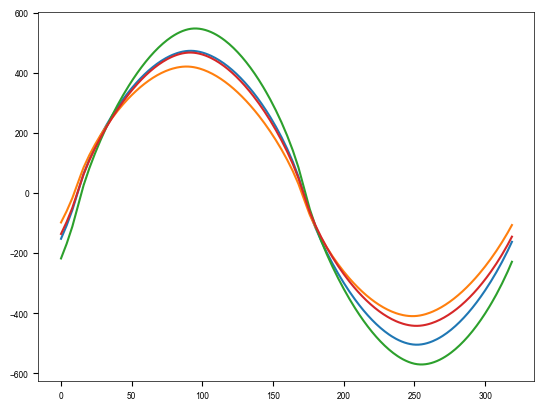

In [91]:
plt.plot(a['xlcc'][:-12:10,0])
plt.plot(a['xlcc'][2:-10:10,0])
plt.plot(a['xlcc'][4:-8:10,0])
plt.plot(a['xlcc'][6:-6:10,0])

In [92]:
a['xlcc'][-1]

array([0.18359906, 0.1835995 , 0.18360006, ..., 0.18398254, 0.18398404,
       0.18398553])